# Analyse budgétaire

Imports

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Chargement des données segmentées

In [27]:
df = pd.read_csv("../data/processed/transactions_segmentees.csv")
df.head()

,transaction_id,customer_id,transaction_date,transaction_time,account_type,payment_method,direction,amount,balance_after,narration,...,weekday,month_name,clean_narration,clean_merchant_name,is_debit,is_credit,transaction_type,time_period,text_to_segment,category
0,TX0000001,CUST0001,2024-01-01,09:34:00,Courant,Virement instantané,Credit,11998.10,19846.02,virement employeur,...,Monday,January,VIREMENT EMPLOYEUR,SALAIRE,0,1,Revenu,Matin,salaire virement employeur,Revenu
1,TX0000003,CUST0001,2024-01-02,09:40:00,Courant,Wallet,Debit,21.55,19824.47,transport careem rabat,...,Tuesday,January,TRANSPORT CAREEM RABAT,CAREEM,1,0,Dépense,Matin,careem transport careem rabat,Transport
2,TX0000002,CUST0001,2024-01-02,11:16:00,Courant,Carte,Debit,147.03,19677.44,carburant shell rabat,...,Tuesday,January,CARBURANT SHELL RABAT,SHELL,1,0,Dépense,Matin,shell carburant shell rabat,Transport
3,TX0000004,CUST0001,2024-01-03,08:53:00,Courant,Carte,Debit,403.15,19274.29,jumia maroc,...,Wednesday,January,JUMIA MAROC,JUMIA,1,0,Dépense,Matin,jumia jumia maroc,E-commerce
4,TX0000005,CUST0001,2024-01-03,18:49:00,Courant,Virement,Debit,775.01,18499.28,loyer appartement rabat,...,Wednesday,January,LOYER APPARTEMENT RABAT,LOYER APPARTEMENT,1,0,Dépense,Soir,loyer appartement loyer appartement rabat,Logement


In [36]:
print(df.columns.tolist())
df[[
    "customer_id",
    "transaction_datetime",
    "year",
    "month",
    "month_name",
    "amount",
    "transaction_type",
    "category",
    "merchant_name"
]].head()

['transaction_id', 'customer_id', 'transaction_date', 'transaction_time', 'account_type', 'payment_method', 'direction', 'amount', 'balance_after', 'narration', 'merchant_name', 'merchant_city', 'merchant_country', 'transaction_datetime', 'year', 'month', 'day', 'hour', 'weekday', 'month_name', 'clean_narration', 'clean_merchant_name', 'is_debit', 'is_credit', 'transaction_type', 'time_period', 'text_to_segment', 'category']


,customer_id,transaction_datetime,year,month,month_name,amount,transaction_type,category,merchant_name
0,CUST0001,2024-01-01 09:34:00,2024,1,January,11998.10,Revenu,Revenu,salaire
1,CUST0001,2024-01-02 09:40:00,2024,1,January,21.55,Dépense,Transport,careem
2,CUST0001,2024-01-02 11:16:00,2024,1,January,147.03,Dépense,Transport,shell
3,CUST0001,2024-01-03 08:53:00,2024,1,January,403.15,Dépense,E-commerce,jumia
4,CUST0001,2024-01-03 18:49:00,2024,1,January,775.01,Dépense,Logement,loyer appartement


Comprendre les montants

In [31]:
df[[
    "amount",
    "transaction_type",
    "category",
    "text_to_segment"
]].sample(15, random_state=42)

,amount,transaction_type,category,text_to_segment
30477,19.28,Dépense,Transport,indrive indrive fès
18203,576.37,Dépense,Voyage,booking booking com
5847,40.86,Dépense,Loisirs,cinéma megarama megarama casablanca
3035,15778.57,Revenu,Revenu,salaire virement salaire
20021,13.09,Dépense,Transport,indrive ride indrive oujda
15526,15.06,Dépense,Alimentation,bim paiement bim oujda
18329,43.96,Dépense,Alimentation,bim bim marrakech
6184,425.05,Dépense,Retrait cash,atm retrait
6367,176.89,Dépense,Shopping,zara zara tanger
5843,116.85,Dépense,Transport,oncf oncf billet rabat


---
### KPI globaux

In [37]:
depenses_par_client = (
    df[df["transaction_type"] == "Dépense"]
    .groupby("customer_id")["amount"]
    .sum()
    .sort_values(ascending=False)
)

depenses_par_client

customer_id
CUST0012    189712.52
CUST0035    185409.45
CUST0007    184775.27
CUST0014    183687.69
CUST0043    181303.12
              ...    
CUST0033     98889.92
CUST0073     98475.60
CUST0067     97761.96
CUST0047     96691.36
CUST0051     92240.13
Name: amount, Length: 75, dtype: float64

---  
### Dépenses par catégorie

In [38]:
depenses_par_categorie = (
    df[df["transaction_type"] == "Dépense"]
    .groupby("category")["amount"]
    .sum()
    .sort_values(ascending=False)
)

depenses_par_categorie

category
Logement        3169102.89
Retrait cash    1076975.07
E-commerce      1052876.95
Santé            955453.66
Alimentation     926517.00
Voyage           849700.59
Shopping         783311.89
Transport        508911.89
Factures         393282.97
Revenu           152747.93
Loisirs           88707.11
Name: amount, dtype: float64

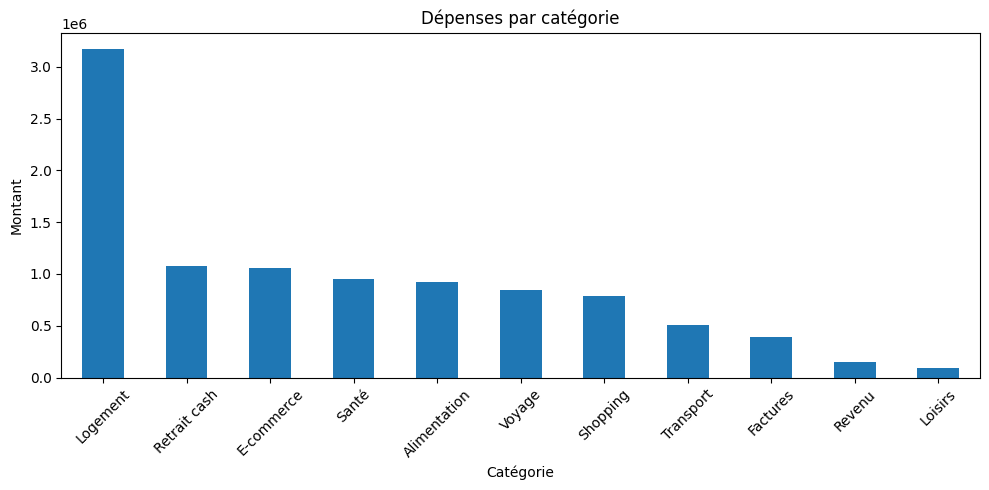

In [39]:
plt.figure(figsize=(10, 5))
depenses_par_categorie.plot(kind="bar")
plt.title("Dépenses par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Montant")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [40]:
part_depenses = (depenses_par_categorie / depenses_par_categorie.sum() * 100).round(2)
part_depenses

category
Logement        31.83
Retrait cash    10.82
E-commerce      10.57
Santé            9.60
Alimentation     9.30
Voyage           8.53
Shopping         7.87
Transport        5.11
Factures         3.95
Revenu           1.53
Loisirs          0.89
Name: amount, dtype: float64

---  
### Analyse par client

Dépenses par client

In [41]:
depenses_par_client = (
    df[df["transaction_type"] == "Dépense"]
    .groupby("customer_id")["amount"]
    .sum()
    .sort_values(ascending=False)
)

depenses_par_client.head(10)

customer_id
CUST0012    189712.52
CUST0035    185409.45
CUST0007    184775.27
CUST0014    183687.69
CUST0043    181303.12
CUST0053    173779.43
CUST0005    173098.18
CUST0003    165570.95
CUST0011    164543.80
CUST0049    158946.98
Name: amount, dtype: float64

Revenus par client

In [42]:
revenus_par_client = (
    df[df["transaction_type"] == "Revenu"]
    .groupby("customer_id")["amount"]
    .sum()
    .sort_values(ascending=False)
)

revenus_par_client.head(10)

customer_id
CUST0035    256542.73
CUST0007    243025.58
CUST0014    237087.89
CUST0043    236586.37
CUST0012    232334.94
CUST0044    217932.00
CUST0053    211578.54
CUST0005    210389.15
CUST0049    199402.09
CUST0011    198396.62
Name: amount, dtype: float64

Tableau propre de synthèse par client

In [43]:
resume_client = (
    df.groupby(["customer_id", "transaction_type"])["amount"]
    .sum()
    .unstack(fill_value=0)
)

resume_client["solde"] = resume_client.get("Revenu", 0) - resume_client.get("Dépense", 0)
resume_client.head()

transaction_type,Dépense,Revenu,solde
customer_id,,,
CUST0001,147233.50,176513.46,29279.96
CUST0002,109145.84,127485.91,18340.07
CUST0003,165570.95,190531.55,24960.60
CUST0004,139526.83,128775.22,-10751.61
CUST0005,173098.18,210389.15,37290.97


Nombre de clients positifs et négatifs

In [44]:
nb_solde_positif = (resume_client["solde"] > 0).sum()
nb_solde_negatif = (resume_client["solde"] < 0).sum()

print("Clients avec solde positif :", nb_solde_positif)
print("Clients avec solde négatif :", nb_solde_negatif)

Clients avec solde positif : 47
Clients avec solde négatif : 28


Cash par client

In [45]:
cash_par_client = (
    df[df["category"] == "Retrait cash"]
    .groupby("customer_id")["amount"]
    .sum()
    .sort_values(ascending=False)
)

cash_par_client.head(10)

customer_id
CUST0014    22048.87
CUST0011    20941.10
CUST0035    20867.02
CUST0012    20776.17
CUST0010    19826.00
CUST0074    19488.41
CUST0043    19444.19
CUST0003    19376.94
CUST0056    19349.17
CUST0065    19203.68
Name: amount, dtype: float64

Part du cash par client

In [46]:
resume_client["cash"] = df[df["category"] == "Retrait cash"] \
    .groupby("customer_id")["amount"].sum()

resume_client["cash"] = resume_client["cash"].fillna(0)

resume_client["part_cash"] = (
    resume_client["cash"] / resume_client["Dépense"] * 100
).round(2)

resume_client.head()

transaction_type,Dépense,Revenu,solde,cash,part_cash
customer_id,,,,,
CUST0001,147233.50,176513.46,29279.96,18269.51,12.41
CUST0002,109145.84,127485.91,18340.07,11194.33,10.26
CUST0003,165570.95,190531.55,24960.60,19376.94,11.70
CUST0004,139526.83,128775.22,-10751.61,13635.62,9.77
CUST0005,173098.18,210389.15,37290.97,16675.06,9.63


TOP marchands

In [47]:
top_marchands = (
    df[df["transaction_type"] == "Dépense"]
    .groupby("merchant_name")["amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_marchands

merchant_name
loyer appartement    3169102.89
atm                  1076975.07
amazon                582128.63
clinique atlas        577719.20
marjane               475043.47
jumia                 470748.32
zara                  419678.54
carrefour             366121.32
bershka               363633.35
booking               333907.35
Name: amount, dtype: float64

Dépenses mensuelles

In [48]:
depenses_mensuelles = (
    df[df["transaction_type"] == "Dépense"]
    .groupby(["year", "month"])["amount"]
    .sum()
    .reset_index()
)

depenses_mensuelles

,year,month,amount
0,2024,1,827486.18
1,2024,2,791117.19
2,2024,3,831204.03
3,2024,4,802753.36
4,2024,5,855942.68
5,2024,6,825411.37
6,2024,7,852394.10
7,2024,8,849486.86
8,2024,9,810670.03
9,2024,10,873902.23


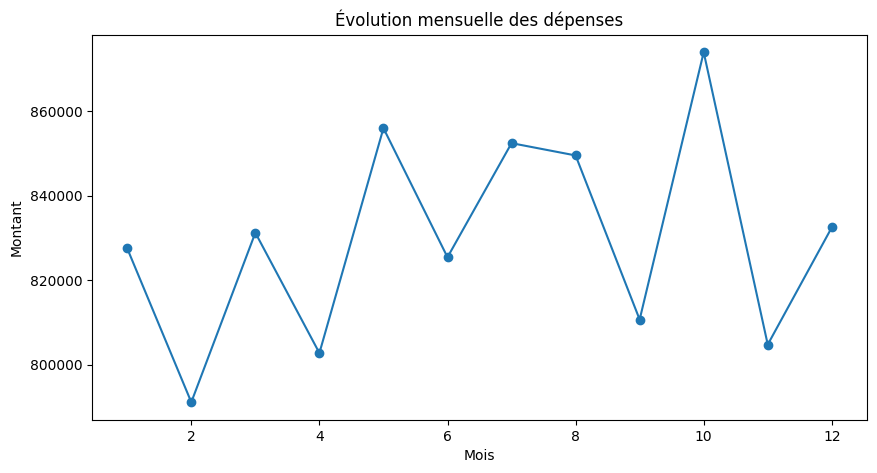

In [49]:
plt.figure(figsize=(10, 5))
plt.plot(depenses_mensuelles["month"], depenses_mensuelles["amount"], marker="o")
plt.title("Évolution mensuelle des dépenses")
plt.xlabel("Mois")
plt.ylabel("Montant")
plt.show()